# Motion Vs Stillness

Purpose: compare empty-room baseline, a person standing still, and a walking person with deterministic CSI so Milestone 4 motion heuristics can be inspected before real captures are required.

Run path: install research extras with `uv sync --extra research`, open this notebook, and choose Run All. The notebook prefers the current simulator and keeps a guarded inline fallback so it still runs before future classifier APIs settle.

Fixture / simulated source: `load_motion_captures` uses `ruview.hardware.simulator.generate_synthetic_window` with `SyntheticCsiConfig(seed=2404, frames=180, sample_rate_hz=20.0)` for `empty_room`, `stillness`, `walking`, and `person_present`. If that import fails, `inline_motion_capture` creates a smaller deterministic NumPy fixture with the same scenario names.


In [1]:
import numpy as np

try:
    import matplotlib.pyplot as plt
except Exception as exc:
    raise RuntimeError('Install the research extra with: uv sync --extra research') from exc

try:
    from ruview.hardware.simulator import SyntheticCsiConfig, generate_synthetic_window
except Exception as exc:
    SyntheticCsiConfig = generate_synthetic_window = None
    SIMULATOR_IMPORT_ERROR = exc
else:
    SIMULATOR_IMPORT_ERROR = None

try:
    import ruview.signal.motion as motion_api
except Exception as exc:
    motion_api = None
    MOTION_API_IMPORT_ERROR = exc
else:
    MOTION_API_IMPORT_ERROR = None

SCENARIOS = ('empty_room', 'stillness', 'walking', 'person_present')
SCENARIO_LABELS = {
    'empty_room': 'empty room baseline',
    'stillness': 'person standing still',
    'walking': 'person walking',
    'person_present': 'static person present',
}
SAMPLE_RATE_HZ = 20.0
FRAMES = 180


def inline_motion_capture(scenario, frames=FRAMES, streams=3, subcarriers=56, seed=2404):
    if scenario not in SCENARIOS:
        raise ValueError(f'unknown scenario: {scenario}')

    rng = np.random.default_rng(seed + SCENARIOS.index(scenario) * 101)
    time_s = np.arange(frames, dtype=float) / SAMPLE_RATE_HZ
    subcarrier_axis = np.linspace(-1.0, 1.0, subcarriers)[None, :]
    stream_axis = np.arange(streams, dtype=float)[:, None]
    base_amp = 1.0 + 0.08 * np.sin(2.0 * np.pi * subcarrier_axis) + 0.03 * stream_axis
    base_phase = 0.10 * subcarrier_axis + 0.30 * stream_axis
    reflection = 0.12 * np.exp(-((subcarrier_axis - 0.20) / 0.28) ** 2)
    capture = np.empty((frames, streams, subcarriers), dtype=np.complex128)

    for frame_index, t in enumerate(time_s):
        slow_drift = 0.004 * np.sin(2.0 * np.pi * 0.03 * t + subcarrier_axis)
        amp = base_amp + slow_drift
        phase = base_phase + 0.002 * np.cos(2.0 * np.pi * 0.05 * t + subcarrier_axis)

        if scenario in {'stillness', 'walking', 'person_present'}:
            amp = 1.20 * amp + reflection
            phase = phase + 0.16 * reflection

        if scenario == 'stillness':
            breathing = 0.020 * np.sin(2.0 * np.pi * 0.25 * t + 0.35 * stream_axis)
            amp = amp + breathing * (0.4 + reflection)
            phase = phase + 0.18 * breathing
        elif scenario == 'walking':
            stride = np.sin(2.0 * np.pi * 0.9 * t + 0.4 * stream_axis + 2.0 * np.pi * subcarrier_axis)
            harmonic = 0.35 * np.sin(2.0 * np.pi * 1.8 * t - np.pi * subcarrier_axis)
            motion = 0.16 * (stride + harmonic) * (0.45 + reflection)
            amp = amp + motion
            phase = phase + 0.45 * motion

        amp = amp + rng.normal(0.0, 0.010, amp.shape)
        phase = phase + rng.normal(0.0, 0.006, phase.shape)
        capture[frame_index] = np.maximum(amp, 1e-6) * np.exp(1j * phase)

    return capture


def load_motion_captures():
    if SyntheticCsiConfig is not None and generate_synthetic_window is not None:
        try:
            config = SyntheticCsiConfig(seed=2404, frames=FRAMES, sample_rate_hz=SAMPLE_RATE_HZ)
            captures = {
                scenario: np.asarray(generate_synthetic_window(scenario, config), dtype=np.complex128)
                for scenario in SCENARIOS
            }
            if all(capture.ndim == 3 for capture in captures.values()):
                return captures, 'ruview.hardware.simulator.generate_synthetic_window'
        except Exception:
            pass

    captures = {scenario: inline_motion_capture(scenario) for scenario in SCENARIOS}
    return captures, 'inline synthetic fallback'


captures, source = load_motion_captures()
time_s = np.arange(FRAMES, dtype=float) / SAMPLE_RATE_HZ
amplitudes = {name: np.abs(capture) for name, capture in captures.items()}

summary = {
    'source': source,
    'shape': captures['empty_room'].shape,
    'sample_rate_hz': SAMPLE_RATE_HZ,
    'future_motion_api_imported': motion_api is not None,
    'mean_amplitude': {
        SCENARIO_LABELS[name]: round(float(amplitudes[name].mean()), 4)
        for name in SCENARIOS
    },
}

summary


{'source': 'ruview.hardware.simulator.generate_synthetic_window',
 'shape': (180, 3, 56),
 'sample_rate_hz': 20.0,
 'future_motion_api_imported': True,
 'mean_amplitude': {'empty room baseline': 0.9984,
  'person standing still': 1.2757,
  'person walking': 1.2734,
  'static person present': 1.2742}}

In [2]:
ROLLING_FRAMES = 16
OPERATING_THRESHOLD = 0.25
REFERENCE_BANDS = [
    (0.00, 0.04, 'absent'),
    (0.04, 0.12, 'present still'),
    (0.12, 0.25, 'present moving'),
    (0.25, 1.00, 'active'),
]


def rolling_mean(values, span):
    values = np.asarray(values, dtype=float)
    smoothed = np.empty_like(values)
    for index in range(values.shape[0]):
        start = max(0, index - span + 1)
        smoothed[index] = values[start:index + 1].mean()
    return smoothed


def raw_motion_features(window, rolling_frames=ROLLING_FRAMES):
    amplitude = np.abs(window)
    phase = np.unwrap(np.unwrap(np.angle(window), axis=2), axis=0)
    diff_energy = np.zeros(amplitude.shape[0], dtype=float)
    phase_step = np.zeros(amplitude.shape[0], dtype=float)
    correlation_drop = np.zeros(amplitude.shape[0], dtype=float)
    rolling_variance = np.empty(amplitude.shape[0], dtype=float)

    for index in range(1, amplitude.shape[0]):
        previous = amplitude[index - 1].ravel()
        current = amplitude[index].ravel()
        diff_energy[index] = np.sqrt(np.mean((current - previous) ** 2)) / (np.mean(previous) + 1e-9)
        phase_step[index] = np.sqrt(np.mean((phase[index] - phase[index - 1]) ** 2))
        if np.std(previous) > 1e-9 and np.std(current) > 1e-9:
            correlation = np.corrcoef(previous, current)[0, 1]
            correlation_drop[index] = max(0.0, (1.0 - correlation) / 2.0)

    for index in range(amplitude.shape[0]):
        start = max(0, index - rolling_frames + 1)
        block = amplitude[start:index + 1]
        rolling_variance[index] = np.mean(np.var(block, axis=0)) / (np.mean(block) ** 2 + 1e-9)

    return {
        'variance': rolling_variance,
        'diff_energy': rolling_mean(diff_energy, 3),
        'phase_step': rolling_mean(phase_step, 3),
        'correlation_drop': rolling_mean(correlation_drop, 3),
    }


def calibrate_components(raw_by_scenario):
    calibration = {}
    for component in ('variance', 'correlation_drop', 'phase_step'):
        floor = float(np.quantile(raw_by_scenario['empty_room'][component], 0.95))
        cap = float(max(np.quantile(raw_by_scenario['walking'][component], 0.90), floor + 1e-9))
        calibration[component] = {'floor': floor, 'cap': cap}
    return calibration


def normalize_components(raw, calibration):
    normalized = {}
    for component, params in calibration.items():
        floor = params['floor']
        span = params['cap'] - floor
        normalized[component] = np.clip((raw[component] - floor) / span, 0.0, 1.0)
    return normalized


def weighted_motion_score(components):
    return np.clip(
        0.40 * components['variance']
        + 0.30 * components['correlation_drop']
        + 0.30 * components['phase_step'],
        0.0,
        1.0,
    )


def optional_library_score(window):
    if motion_api is None:
        return None, 'not available'

    for function_name in ('score_motion_series', 'motion_score_series', 'calculate_motion_score_series'):
        candidate = getattr(motion_api, function_name, None)
        if not callable(candidate):
            continue
        try:
            result = candidate(window, sample_rate_hz=SAMPLE_RATE_HZ)
            values = np.asarray(result, dtype=float)
            if values.shape == (window.shape[0],):
                return np.clip(values, 0.0, 1.0), f'ruview.signal.motion.{function_name}'
        except Exception:
            continue

    return None, 'no compatible scorer found'


raw_by_scenario = {name: raw_motion_features(capture) for name, capture in captures.items()}
calibration = calibrate_components(raw_by_scenario)
local_components = {
    name: normalize_components(raw_features, calibration)
    for name, raw_features in raw_by_scenario.items()
}
local_scores = {
    name: weighted_motion_score(components)
    for name, components in local_components.items()
}

motion_scores = {}
score_sources = {}
for name, capture in captures.items():
    library_score, library_source = optional_library_score(capture)
    if library_score is None:
        motion_scores[name] = local_scores[name]
        score_sources[name] = 'notebook fallback: variance/correlation/phase weighted score'
    else:
        motion_scores[name] = library_score
        score_sources[name] = library_source

score_summary = {
    SCENARIO_LABELS[name]: {
        'score_source': score_sources[name],
        'mean_score': round(float(motion_scores[name].mean()), 4),
        'p95_score': round(float(np.quantile(motion_scores[name], 0.95)), 4),
        'max_score': round(float(motion_scores[name].max()), 4),
        'rolling_variance_mean': round(float(raw_by_scenario[name]['variance'].mean()), 6),
    }
    for name in SCENARIOS
}

score_summary


{'empty room baseline': {'score_source': 'notebook fallback: variance/correlation/phase weighted score',
  'mean_score': 0.006,
  'p95_score': 0.0155,
  'max_score': 0.3,
  'rolling_variance_mean': 0.000377},
 'person standing still': {'score_source': 'notebook fallback: variance/correlation/phase weighted score',
  'mean_score': 0.0,
  'p95_score': 0.0,
  'max_score': 0.0,
  'rolling_variance_mean': 0.000244},
 'person walking': {'score_source': 'notebook fallback: variance/correlation/phase weighted score',
  'mean_score': 0.491,
  'p95_score': 0.7,
  'max_score': 0.8449,
  'rolling_variance_mean': 0.008429},
 'static person present': {'score_source': 'notebook fallback: variance/correlation/phase weighted score',
  'mean_score': 0.0,
  'p95_score': 0.0,
  'max_score': 0.0,
  'rolling_variance_mean': 0.000228}}

/var/folders/sy/rs3wfmrj5sxfqw_kfbymtrfr0000gn/T/ipykernel_92273/289598403.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot(


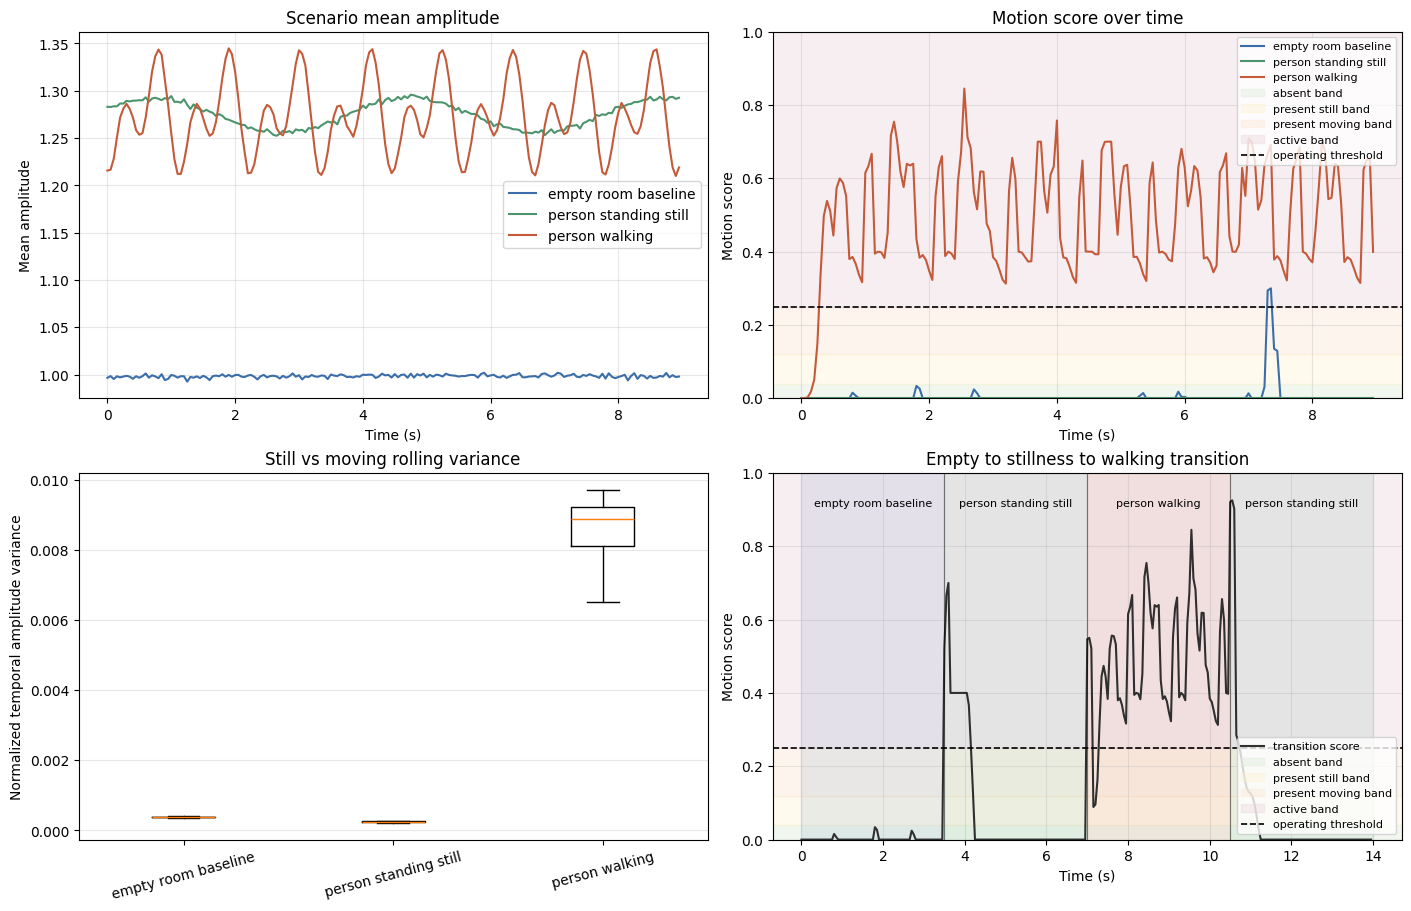

In [3]:
PALETTE = {
    'empty_room': '#3b6ea8',
    'stillness': '#4c956c',
    'walking': '#c45a3a',
    'person_present': '#7b5ea7',
}
BAND_COLORS = ['#d9ead3', '#fff2cc', '#fce5cd', '#ead1dc']


def draw_threshold_bands(axis):
    for (low, high, label), color in zip(REFERENCE_BANDS, BAND_COLORS):
        axis.axhspan(low, high, color=color, alpha=0.35, label=f'{label} band')
    axis.axhline(OPERATING_THRESHOLD, color='black', linestyle='--', linewidth=1.2, label='operating threshold')
    axis.set_ylim(0.0, 1.0)


def build_transition_capture(segment_frames=70):
    order = ('empty_room', 'stillness', 'walking', 'stillness')
    pieces = [captures[name][:segment_frames] for name in order]
    transition = np.concatenate(pieces, axis=0)
    boundaries = np.cumsum([0] + [piece.shape[0] for piece in pieces])
    raw = raw_motion_features(transition)
    score = weighted_motion_score(normalize_components(raw, calibration))
    return transition, score, order, boundaries


transition_capture, transition_score, transition_order, transition_boundaries = build_transition_capture()
transition_time_s = np.arange(transition_score.shape[0], dtype=float) / SAMPLE_RATE_HZ

fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)

for name in ('empty_room', 'stillness', 'walking'):
    mean_amp = amplitudes[name].mean(axis=(1, 2))
    axes[0, 0].plot(time_s, mean_amp, color=PALETTE[name], label=SCENARIO_LABELS[name])
axes[0, 0].set_title('Scenario mean amplitude')
axes[0, 0].set_xlabel('Time (s)')
axes[0, 0].set_ylabel('Mean amplitude')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend(loc='best')

for name in ('empty_room', 'stillness', 'walking'):
    axes[0, 1].plot(time_s, motion_scores[name], color=PALETTE[name], label=SCENARIO_LABELS[name])
draw_threshold_bands(axes[0, 1])
axes[0, 1].set_title('Motion score over time')
axes[0, 1].set_xlabel('Time (s)')
axes[0, 1].set_ylabel('Motion score')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend(loc='upper right', fontsize=8)

variance_series = [raw_by_scenario[name]['variance'] for name in ('empty_room', 'stillness', 'walking')]
axes[1, 0].boxplot(
    variance_series,
    labels=[SCENARIO_LABELS[name] for name in ('empty_room', 'stillness', 'walking')],
    showfliers=False,
)
axes[1, 0].set_title('Still vs moving rolling variance')
axes[1, 0].set_ylabel('Normalized temporal amplitude variance')
axes[1, 0].tick_params(axis='x', labelrotation=15)
axes[1, 0].grid(True, axis='y', alpha=0.3)

axes[1, 1].plot(transition_time_s, transition_score, color='#2f2f2f', label='transition score')
draw_threshold_bands(axes[1, 1])
for start, end, name in zip(transition_boundaries[:-1], transition_boundaries[1:], transition_order):
    axes[1, 1].axvspan(start / SAMPLE_RATE_HZ, end / SAMPLE_RATE_HZ, color=PALETTE[name], alpha=0.10)
    axes[1, 1].text(
        (start + end) / (2.0 * SAMPLE_RATE_HZ),
        0.93,
        SCENARIO_LABELS[name],
        ha='center',
        va='top',
        fontsize=8,
    )
for boundary in transition_boundaries[1:-1]:
    axes[1, 1].axvline(boundary / SAMPLE_RATE_HZ, color='black', linewidth=0.8, alpha=0.45)
axes[1, 1].set_title('Empty to stillness to walking transition')
axes[1, 1].set_xlabel('Time (s)')
axes[1, 1].set_ylabel('Motion score')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend(loc='lower right', fontsize=8)

plt.show()


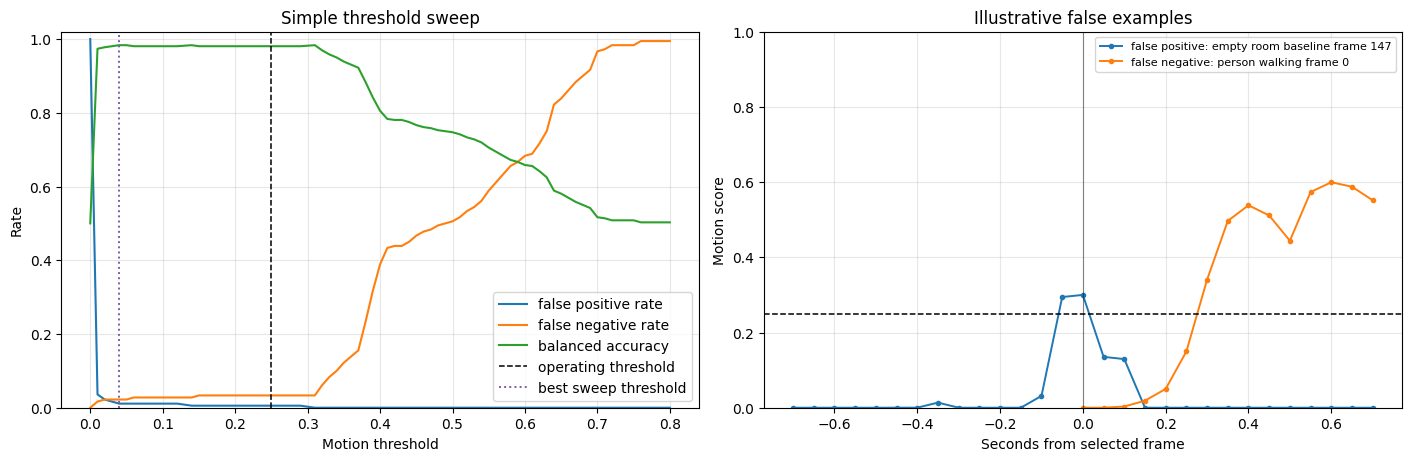

{'operating_threshold': 0.25,
 'best_sweep_threshold': 0.04,
 'best_balanced_accuracy': 0.9833,
 'false_examples': [{'kind': 'false positive',
   'scenario': 'empty_room',
   'frame_index': 147,
   'score': 0.3},
  {'kind': 'false negative',
   'scenario': 'walking',
   'frame_index': 0,
   'score': 0.0}]}

In [4]:
def evaluation_rows(scores_by_scenario):
    rows = []
    for scenario in ('empty_room', 'stillness', 'walking'):
        target_is_moving = scenario == 'walking'
        for frame_index, score in enumerate(scores_by_scenario[scenario]):
            rows.append({
                'scenario': scenario,
                'frame_index': frame_index,
                'score': float(score),
                'moving': target_is_moving,
            })
    return rows


def threshold_sweep(rows, thresholds):
    labels = np.array([row['moving'] for row in rows], dtype=bool)
    scores = np.array([row['score'] for row in rows], dtype=float)
    sweep = []
    for threshold in thresholds:
        predictions = scores >= threshold
        true_positive = np.sum(predictions & labels)
        true_negative = np.sum(~predictions & ~labels)
        false_positive = np.sum(predictions & ~labels)
        false_negative = np.sum(~predictions & labels)
        fpr = false_positive / max(false_positive + true_negative, 1)
        fnr = false_negative / max(false_negative + true_positive, 1)
        tpr = true_positive / max(true_positive + false_negative, 1)
        tnr = true_negative / max(true_negative + false_positive, 1)
        sweep.append({
            'threshold': float(threshold),
            'false_positive_rate': float(fpr),
            'false_negative_rate': float(fnr),
            'balanced_accuracy': float((tpr + tnr) / 2.0),
        })
    return sweep


def pick_false_examples(rows, threshold):
    false_positives = [row for row in rows if row['score'] >= threshold and not row['moving']]
    false_negatives = [row for row in rows if row['score'] < threshold and row['moving']]
    examples = []
    if false_positives:
        examples.append(('false positive', max(false_positives, key=lambda row: row['score'])))
    if false_negatives:
        examples.append(('false negative', min(false_negatives, key=lambda row: row['score'])))
    return examples


rows = evaluation_rows(motion_scores)
thresholds = np.linspace(0.0, 0.80, 81)
sweep = threshold_sweep(rows, thresholds)
best = max(sweep, key=lambda row: row['balanced_accuracy'])
examples = pick_false_examples(rows, OPERATING_THRESHOLD)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), constrained_layout=True)

axes[0].plot(thresholds, [row['false_positive_rate'] for row in sweep], label='false positive rate')
axes[0].plot(thresholds, [row['false_negative_rate'] for row in sweep], label='false negative rate')
axes[0].plot(thresholds, [row['balanced_accuracy'] for row in sweep], label='balanced accuracy')
axes[0].axvline(OPERATING_THRESHOLD, color='black', linestyle='--', linewidth=1.1, label='operating threshold')
axes[0].axvline(best['threshold'], color='#7b5ea7', linestyle=':', linewidth=1.4, label='best sweep threshold')
axes[0].set_title('Simple threshold sweep')
axes[0].set_xlabel('Motion threshold')
axes[0].set_ylabel('Rate')
axes[0].set_ylim(0.0, 1.02)
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='best')

if examples:
    for label, row in examples:
        scenario = row['scenario']
        scores = motion_scores[scenario]
        center = row['frame_index']
        start = max(0, center - 14)
        end = min(scores.shape[0], center + 15)
        local_time = (np.arange(start, end) - center) / SAMPLE_RATE_HZ
        axes[1].plot(
            local_time,
            scores[start:end],
            marker='o',
            linewidth=1.4,
            markersize=3,
            label=f'{label}: {SCENARIO_LABELS[scenario]} frame {center}',
        )
    axes[1].axhline(OPERATING_THRESHOLD, color='black', linestyle='--', linewidth=1.1)
    axes[1].axvline(0.0, color='black', linewidth=0.8, alpha=0.45)
    axes[1].set_title('Illustrative false examples')
    axes[1].set_xlabel('Seconds from selected frame')
    axes[1].set_ylabel('Motion score')
    axes[1].set_ylim(0.0, 1.0)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='best', fontsize=8)
else:
    axes[1].text(0.5, 0.5, 'No false examples at the operating threshold', ha='center', va='center')
    axes[1].set_axis_off()

plt.show()

{
    'operating_threshold': OPERATING_THRESHOLD,
    'best_sweep_threshold': round(best['threshold'], 3),
    'best_balanced_accuracy': round(best['balanced_accuracy'], 4),
    'false_examples': [
        {
            'kind': label,
            'scenario': row['scenario'],
            'frame_index': row['frame_index'],
            'score': round(row['score'], 4),
        }
        for label, row in examples
    ],
}


Expected interpretation: the empty-room baseline and standing-still person should sit mostly in the low-score bands, while walking should lift rolling variance, decorrelation, and phase-step components into the moving or active bands. The transition plot should lag slightly at state changes because the notebook uses a rolling window, which is useful for seeing how smoothing creates early false negatives and occasional baseline false positives.

Limitations: this is a research-first visual lab, not the final presence classifier. The fallback score intentionally approximates the Rust references with variance, correlation, and phase indicators, but it calibrates on known synthetic empty/walking captures and does not model packet loss, antenna geometry, calibration drift, environmental motion, multiperson scenes, or real ESP32 timing.
